In [35]:
import pandas as pd

df = pd.read_csv("../Data/EAL_Barreras_2026_11_05.csv")


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df.copy()

# Rinominare motivo_corto in barrera se non l'hai già fatto
df_plot = df_plot.rename(columns={'motivo_corto': 'barrera'})

# Filtrar solo 50-499 y Servicios
df_plot_filtrado = df_plot[df_plot['segmento'].isin(['50-499 empleados', 'Servicios'])]



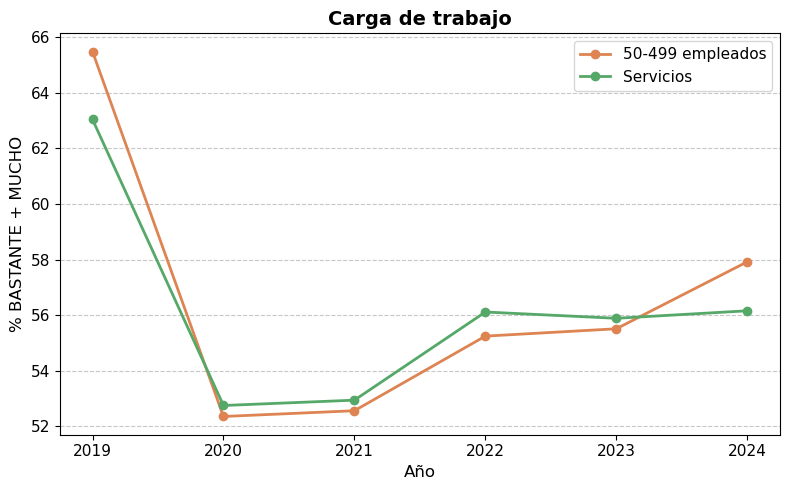

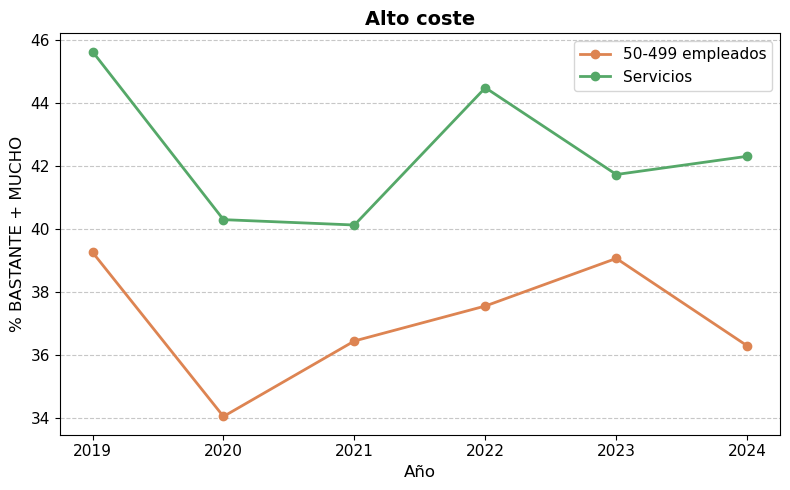

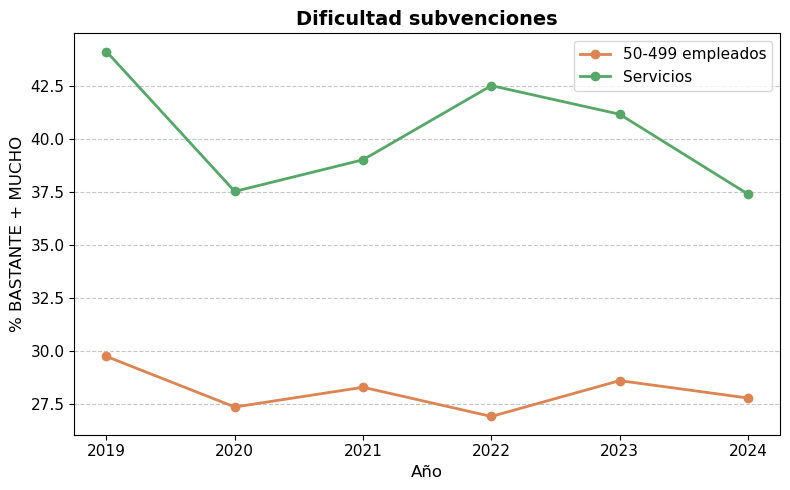

In [37]:
import matplotlib.pyplot as plt

colores = {
    '50-499 empleados': '#DD8452',
    'Servicios':        '#55A868'
}

for barrera in ['Carga de trabajo', 'Alto coste', 'Dificultad subvenciones']:
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    df_b = df_plot_filtrado[df_plot_filtrado['barrera'] == barrera]
    
    for segmento, color in colores.items():
        df_s = df_b[df_b['segmento'] == segmento]
        ax.plot(df_s['año'], df_s['valor'],
                marker='o', label=segmento, color=color, linewidth=2)
    
    ax.set_title(barrera, fontsize=14, fontweight='bold')
    ax.set_xlabel('Año', fontsize=12)
    ax.set_ylabel('% BASTANTE + MUCHO', fontsize=12)
    ax.set_xticks(range(2019, 2025))
    ax.tick_params(axis='both', labelsize=11)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.savefig(f"barrera_{barrera.replace(' ', '_')}.png", dpi=300, bbox_inches='tight')
    plt.show()

## considero SERVICIO como referencia de segmento

In [38]:
# Filtrar solo Servicios
df_ranking = df_plot_filtrado[df_plot_filtrado['segmento'] == 'Servicios'].copy()

# Pivot para tener años como columnas
df_ranking = df_ranking.pivot(index='barrera', columns='año', values='valor')

# Calcular variación 2019 vs 2024
df_ranking['Crecimiento Total'] = df_ranking[2024] - df_ranking[2019]

# Ordenar
df_ranking = df_ranking.sort_values(by='Crecimiento Total', ascending=False)

print("Ranking de Variación de Barreras a la Formación (Servicios)")
print(df_ranking[['Crecimiento Total']])

Ranking de Variación de Barreras a la Formación (Servicios)
año                      Crecimiento Total
barrera                                   
Alto coste                          -3.320
Dificultad subvenciones             -6.728
Carga de trabajo                    -6.882


In [39]:
df_ranking['Media 2019-2024'] = df_ranking.loc[:, 2019:2024].mean(axis=1)
df_ranking['Valor 2024'] = df_ranking[2024]

print(df_ranking[['Valor 2024', 'Media 2019-2024', 'Crecimiento Total']])

año                      Valor 2024  Media 2019-2024  Crecimiento Total
barrera                                                                
Alto coste                   42.310        42.431333             -3.320
Dificultad subvenciones      37.398        40.292000             -6.728
Carga de trabajo             56.156        56.147000             -6.882


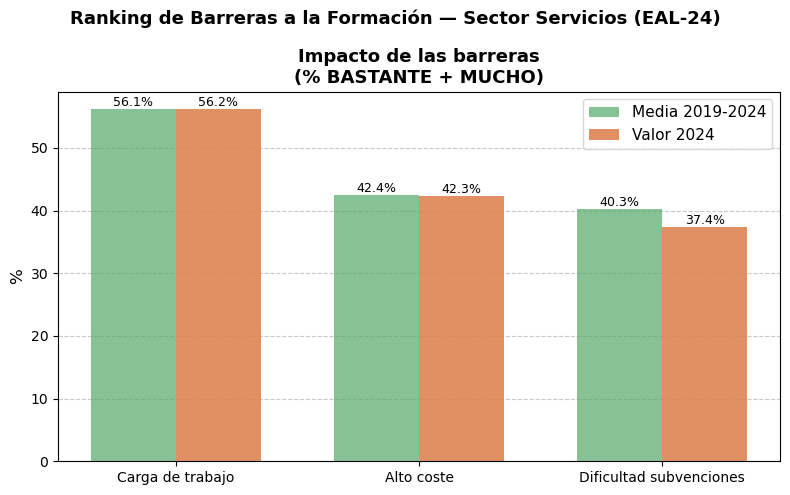

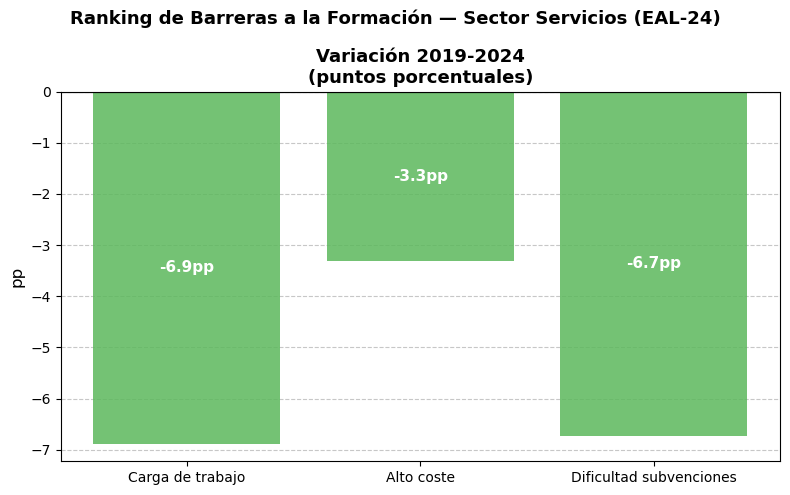

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Datos del ranking
barreras = ['Carga de trabajo', 'Alto coste', 'Dificultad subvenciones']
valor_2024 = [56.156, 42.310, 37.398]
media = [56.147, 42.431, 40.292]
tendencia = [-6.882, -3.320, -6.728]

x = np.arange(len(barreras))
width = 0.35

# -------------------------------------------------------
# FIGURA 1 — Impacto absoluto
# -------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(x - width/2, media, width, label='Media 2019-2024', color='#55A868', alpha=0.7)
ax1.bar(x + width/2, valor_2024, width, label='Valor 2024', color='#DD8452', alpha=0.9)

ax1.set_title('Impacto de las barreras\n(% BASTANTE + MUCHO)', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(barreras, fontsize=11)
ax1.set_ylabel('%', fontsize=12)
ax1.tick_params(axis='both', labelsize=10)
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)
ax1.legend(fontsize=11)

for i, (m, v) in enumerate(zip(media, valor_2024)):
    ax1.text(i - width/2, m + 0.5, f'{m:.1f}%', ha='center', fontsize=9)
    ax1.text(i + width/2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Ranking de Barreras a la Formación — Sector Servicios (EAL-24)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("ranking_barreras_impacto.png", dpi=300, bbox_inches='tight')
plt.show()

# -------------------------------------------------------
# FIGURA 2 — Tendencia 2019-2024
# -------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 5))

colores_tend = ['#d9534f' if t > 0 else '#5cb85c' for t in tendencia]
bars = ax2.bar(barreras, tendencia, color=colores_tend, alpha=0.85)

ax2.set_title('Variación 2019-2024\n(puntos porcentuales)', fontsize=13, fontweight='bold')
ax2.set_ylabel('pp', fontsize=12)
ax2.tick_params(axis='both', labelsize=10)
ax2.yaxis.grid(True, linestyle='--', alpha=0.7)
ax2.set_axisbelow(True)
ax2.axhline(y=0, color='black', linewidth=0.8)

for bar, t in zip(bars, tendencia):
    ax2.text(bar.get_x() + bar.get_width()/2, t/2,
             f'{t:.1f}pp', ha='center', va='center',
             fontsize=11, fontweight='bold', color='white')

plt.suptitle('Ranking de Barreras a la Formación — Sector Servicios (EAL-24)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("ranking_barreras_tendencia.png", dpi=300, bbox_inches='tight')
plt.show()

In [41]:
df_ranking

año,2019,2020,2021,2022,2023,2024,Crecimiento Total,Media 2019-2024,Valor 2024
barrera,,,,,,,,,
Alto coste,45.630,40.301,40.131,44.484,41.732,42.310,-3.320,42.431333,42.310
Dificultad subvenciones,44.126,37.524,39.018,42.519,41.167,37.398,-6.728,40.292000,37.398
Carga de trabajo,63.038,52.749,52.941,56.112,55.886,56.156,-6.882,56.147000,56.156


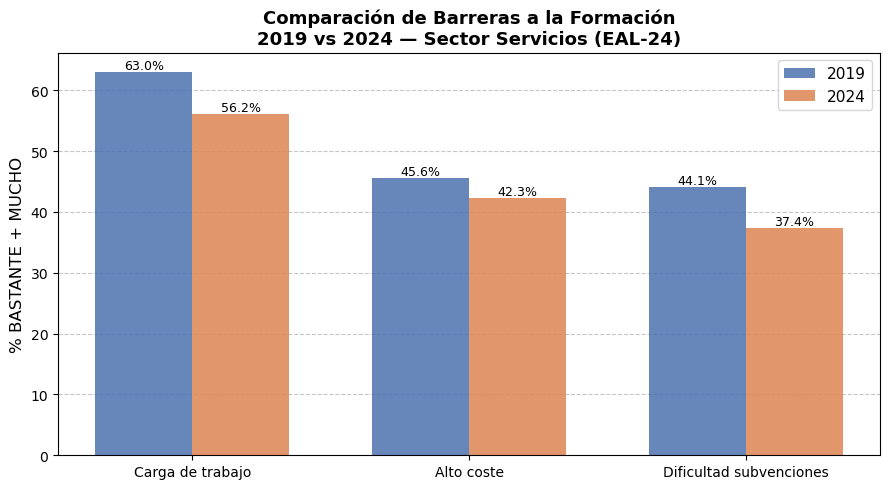

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Datos exactos del df_ranking
barreras = ['Carga de trabajo', 'Alto coste', 'Dificultad subvenciones']
valor_2019 = [63.038, 45.630, 44.126]
valor_2024 = [56.156, 42.310, 37.398]

x = np.arange(len(barreras))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - width/2, valor_2019, width, label='2019', color='#4C72B0', alpha=0.85)
ax.bar(x + width/2, valor_2024, width, label='2024', color='#DD8452', alpha=0.85)

ax.set_title('Comparación de Barreras a la Formación\n2019 vs 2024 — Sector Servicios (EAL-24)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(barreras, fontsize=11)
ax.set_ylabel('% BASTANTE + MUCHO', fontsize=12)
ax.tick_params(axis='both', labelsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.legend(fontsize=11)

for i, (v19, v24) in enumerate(zip(valor_2019, valor_2024)):
    ax.text(i - width/2, v19 + 0.5, f'{v19:.1f}%', ha='center', fontsize=9)
    ax.text(i + width/2, v24 + 0.5, f'{v24:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
#plt.savefig("comparacion_2019_2024.png", dpi=300, bbox_inches='tight')
plt.show()

In [43]:
from scipy.stats import friedmanchisquare

# Extraer valores por barrera para Servicios
carga = df_plot_filtrado[
    (df_plot_filtrado['segmento'] == 'Servicios') & 
    (df_plot_filtrado['barrera'] == 'Carga de trabajo')
]['valor'].values

coste = df_plot_filtrado[
    (df_plot_filtrado['segmento'] == 'Servicios') & 
    (df_plot_filtrado['barrera'] == 'Alto coste')
]['valor'].values

subv = df_plot_filtrado[
    (df_plot_filtrado['segmento'] == 'Servicios') & 
    (df_plot_filtrado['barrera'] == 'Dificultad subvenciones')
]['valor'].values

print("Valores Carga:", carga)
print("Valores Alto coste:", coste)
print("Valores Subvenciones:", subv)

# Test de Friedman
stat, p = friedmanchisquare(carga, coste, subv)
print(f"\nFriedman: stat={stat:.3f}, p={p:.4f}")

if p < 0.05:
    print("✅ Las barreras son significativamente diferentes entre sí")
else:
    print("❌ No hay diferencias significativas entre las barreras")

Valores Carga: [63.038 52.749 52.941 56.112 55.886 56.156]
Valores Alto coste: [45.63  40.301 40.131 44.484 41.732 42.31 ]
Valores Subvenciones: [44.126 37.524 39.018 42.519 41.167 37.398]

Friedman: stat=12.000, p=0.0025
✅ Las barreras son significativamente diferentes entre sí


1. Formación flexible para combatir la carga de trabajo
Dato que lo justifica: 56.2% de las empresas del sector lo identifica como barrera principal.
La formación no puede competir con la operativa — tiene que integrarse en ella. Las tendencias del sector apuntan a:

Microformación — sesiones de 15-20 minutos integradas en la jornada
E-learning asíncrono — el empleado forma cuando puede, no cuando el calendario lo impone
Formación en el puesto — aprendizaje mientras se trabaja, especialmente útil en logística y transporte
Rotación de turnos para liberar tiempo formativo sin impactar la operativa


2. Activar la financiación pública — FUNDAE
Dato que lo justifica: 42.3% percibe el alto coste como barrera y solo el 26% de empresas detecta necesidades formativas de forma proactiva (EAL-18).
El sector está dejando dinero sobre la mesa. Las empresas con entre 50-249 trabajadores tienen un crédito FUNDAE anual que en muchos casos no se consume. Estrategias concretas:

Designar un responsable interno de gestión de FUNDAE
Planificar el calendario formativo anual vinculado al crédito disponible
Agrupar formaciones para maximizar el uso del crédito
Explorar bonificaciones adicionales por formación en competencias digitales


3. Diagnóstico previo de necesidades formativas
Dato que lo justifica: solo el 25.9% de empresas de Transporte y Almacenamiento detecta necesidades formativas antes de formar (EAL-18) — por debajo de la media nacional del 29.1%.
El sector forma mucho pero sin estrategia. Para Rapid Express esto significa:

Implementar una evaluación anual de competencias por puesto
Cruzar las competencias actuales con las que el sector considera críticas para el futuro (EAL-16): trabajo en equipo (46.8% muy importante), atención al cliente (44.3%), resolución de problemas (34.3%)
Crear un mapa de brecha formativa — dónde estamos vs dónde necesitamos estar


4. Priorizar las competencias del futuro
Dato que lo justifica: EAL-16 y EAL-20 muestran una brecha entre lo que el sector forma hoy y lo que considera importante para los próximos años.
CompetenciaImportancia futuraFormación actualTrabajo en equipo46.8% muy importante28.5% la formaAtención al cliente44.3% muy importante24.5% la formaResolución de problemas34.3% muy importante11.2% la formaTIC generales17.9% muy importante12.7% la forma
La brecha más grande está en resolución de problemas y trabajo en equipo — competencias críticas para operaciones logísticas complejas.

5. Construir una cultura formativa interna
Dato que lo justifica: el 73.4% del sector forma (EAL-17) pero la mayoría lo hace de forma reactiva, sin detección previa de necesidades.
La diferencia entre formar y desarrollar talento está en la cultura. Acciones concretas:

Plan de Desarrollo Individual (PDI) para cada empleado — objetivos formativos anuales vinculados al desempeño
Mentoring interno — los empleados más experimentados forman a los nuevos, reduciendo coste y tiempo
Reconocimiento de la formación — vincular la formación completada a la carrera profesional interna
Comunicación interna sobre el valor de la formación — hacer visible el ROI formativo